# data loading


In [2]:
import pandas as pd
fake=pd.read_csv("Fake.csv")
true=pd.read_csv("True.csv")
fake["label"]=0
true["label"]=1
df=pd.concat([fake,true],ignore_index=True)
df=df.sample(frac=1,random_state=42)
df.head()

,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
27917,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
25007,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
32476,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# Exploratory Data Analysis

In [3]:
#dataset shape
df.shape

(44898, 5)

In [4]:
#missing value
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

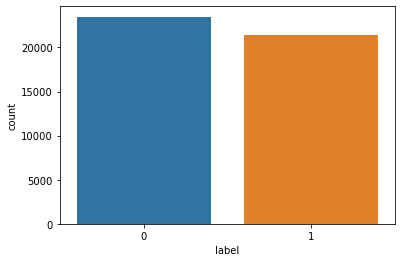

In [5]:
#class distribution 
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='label',data=df)
plt.show()

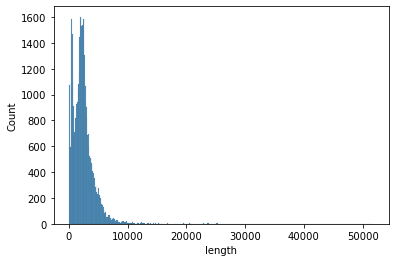

In [6]:
#news length
df['length']=df['text'].apply(len)
sns.histplot(df['length'])
plt.show()

# text cleaning 

In [7]:
import re
def clean_text(text):
    text=str(text)
    text=text.lower()
    text=re.sub(r'http\\S+','',text)
    text=re.sub(r'[^a-zA-Z]','',text)
    return text
df['text'].apply(clean_text)
df['text']

22216    21st Century Wire says Ben Stein, reputable pr...
27917    WASHINGTON (Reuters) - U.S. President Donald T...
25007    (Reuters) - Puerto Rico Governor Ricardo Rosse...
1377     On Monday, Donald Trump once again embarrassed...
32476    GLASGOW, Scotland (Reuters) - Most U.S. presid...
                               ...                        
11284                                                     
44732    LONDON/TOKYO (Reuters) - British Prime Ministe...
38158    BERLIN (Reuters) - Chancellor Angela Merkel sa...
860      Jesus f*cking Christ our President* is a moron...
15795    IF SHE S NOT TOAST NOW THEN WE RE IN BIGGER TR...
Name: text, Length: 44898, dtype: object

# train test data


In [8]:
print(df.shape)

(44898, 6)


In [9]:
!pip install scikit-learn


In [10]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'length'], dtype='object')


In [11]:
X=df['text']
y=df['label']
print(type(X))
print(type(y))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [12]:
print(len(X))
print(len(y))

44898
44898


In [13]:
from sklearn.model_selection import train_test_split

In [31]:
from sklearn.model_selection import train_test_split

x = df['text']
y = df['label']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("done")

done


# feature extraction

In [15]:
print(df['text'].head())

22216    21st Century Wire says Ben Stein, reputable pr...
27917    WASHINGTON (Reuters) - U.S. President Donald T...
25007    (Reuters) - Puerto Rico Governor Ricardo Rosse...
1377     On Monday, Donald Trump once again embarrassed...
32476    GLASGOW, Scotland (Reuters) - Most U.S. presid...
Name: text, dtype: object


In [20]:
print(X_train)

22686    Tune in to the Alternate Current Radio Network...
37230    CARACAS (Reuters) - A general appointed at the...
44558    ISTANBUL (Reuters) - Turkey s European Union A...
17528    Democrat Senator Kristen Gillibrand (NY) likes...
32362    WASHINGTON (Reuters) - U.S. Republican preside...
                               ...                        
1564     Last year, Trump claimed he was succeeding at ...
27251    WASHINGTON (Reuters) - U.S. appeals court judg...
4150     Terrified and unable to accept that he s destr...
15789    This mayor s involvement in potential illegal ...
10925    There are 20 Democrats who at certain times ha...
Name: text, Length: 35918, dtype: object


In [28]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'DecisionTreeClassifier', 'model', '_i2', 'pd', 'fake', 'true', 'df', '_2', '_i3', '_3', '_i4', '_4', '_i5', 'sns', 'plt', '_i6', '_i7', 're', 'clean_text', '_7', '_i8', '_i9', '_exit_code', '_i10', '_i11', 'X', 'y', '_i12', '_i13', 'train_test_split', '_i14', 'X_train', 'X_test', 'y_train', 'y_test', '_i15', '_i16', 'TfidfVectorizer', 'vectorizer', '_i17', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28'])


In [34]:
print(type(x_train))
print(type(y_train))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=5000
)
X_train=vectorizer.fit_transform(x_train)
X_test=vectorizer.transform(x_test)
print(X_train.shape)
print("TF-IDF completed")

(35918, 5000)
TF-IDF completed


# model

In [37]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=None
)

model.fit(X_train, y_train)

DecisionTreeClassifier()

# evaluation

In [38]:
train_acc= model.score(X_train, y_train)
test_acc=model.score(X_test, y_test)
print("Train: ",train_acc)
print("Test: ",test_acc)

Train:  0.9999721588061696
Test:  0.995879732739421


# confusion matrix

<AxesSubplot:>

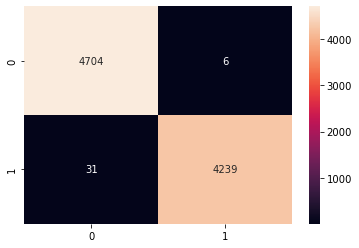

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
pred=model.predict(X_test)
cm=confusion_matrix(y_test,pred)
sns.heatmap(cm, annot=True, fmt='d')

In [41]:
#regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [45]:
print("train:")
print(lr.score(X_train, y_train))
print("test:")
print(lr.score(X_test,y_test))

train:
0.9910072943927836
test:
0.9846325167037862


In [46]:
def predict_news(news):
    news_vector=vectorizer.transform([news])
    prediction=lr.predict(news_vector)
    if prediction[0]==1:
        return "REAL NEWS"
    else:
        return "FAKE NEWS"

In [58]:
#test
sample="india launched a new satellite successfully today."
print(predict_news("NEW DELHI (Reuters) - The Indian Space Research Organisation (ISRO) on Thursday successfully launched a communication satellite from the Satish Dhawan Space Centre. Officials said the launch vehicle performed as expected and placed the satellite into its designated orbit. The mission is expected to improve communication services across several regions of the country."))
print(predict_news(sample))

REAL NEWS
FAKE NEWS


In [7]:
!pip freeze > requirements.txt

In [8]:
!type requirements.txt

aiohttp @ file:///C:/ci/aiohttp_1646806572557/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
alabaster @ file:///home/ktietz/src/ci/alabaster_1611921544520/work
anaconda-client @ file:///C:/ci/anaconda-client_1635342725944/work
anaconda-navigator==2.1.4
anaconda-project @ file:///tmp/build/80754af9/anaconda-project_1637161053845/work
anyio @ file:///C:/ci/anyio_1644481921011/work/dist
appdirs==1.4.4
argon2-cffi @ file:///opt/conda/conda-bld/argon2-cffi_1645000214183/work
argon2-cffi-bindings @ file:///C:/ci/argon2-cffi-bindings_1644551690056/work
arrow @ file:///opt/conda/conda-bld/arrow_1649166651673/work
astroid @ file:///C:/ci/astroid_1628063282661/work
astropy @ file:///C:/ci/astropy_1650634291321/work
asttokens @ file:///opt/conda/conda-bld/asttokens_1646925590279/work
async-timeout @ file:///tmp/build/80754af9/async-timeout_1637851218186/work
atomicwrites==1.4.0
attrs @ file:///opt/conda/conda-bld/attrs_1642510447205/work
Automat @ file:///tmp/build/8075